In [ ]:
#importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from sklearn.cluster import KMeans

In [25]:
#loading and exploration of dataset
wage= pd.read_csv("minimum wage data.csv")
wage.head()

,Y,X1,X2,X3,X4,X5,YEAR,STATES
0,0,0,32967.37181,68762.37475,31488.52918,15499.92926,2019,ABIA
1,0,0,48369.06408,89139.25072,36877.83854,15921.22618,2020,ABIA
2,0,0,39512.62077,95212.68753,42289.20611,19578.33159,2021,ABIA
3,0,0,59350.76252,103710.01110,42289.20611,20108.23206,2022,ABIA
4,0,0,125920.00000,138638.00740,89053.93930,20108.23206,2023,ABIA


In [26]:
wage.index

RangeIndex(start=0, stop=180, step=1)

In [27]:
wage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Y       180 non-null    int64  
 1   X1      180 non-null    int64  
 2   X2      180 non-null    float64
 3   X3      180 non-null    float64
 4   X4      180 non-null    float64
 5   X5      180 non-null    float64
 6   YEAR    180 non-null    int64  
 7   STATES  180 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 11.4+ KB


In [28]:
wage.describe()

,Y,X1,X2,X3,X4,X5,YEAR
count,180.000000,180.000000,180.000000,1.800000e+02,1.800000e+02,180.000000,180.000000
mean,0.583333,0.583333,85281.499082,1.330188e+05,6.582795e+04,46640.542398,2021.000000
std,0.494382,0.494382,74781.355335,1.201554e+05,1.293718e+05,110073.526498,1.418158
min,0.000000,0.000000,18993.585770,2.897703e+04,5.577419e+03,6182.963983,2019.000000
25%,0.000000,0.000000,43046.837805,7.140095e+04,1.994027e+04,13516.368960,2020.000000
50%,1.000000,1.000000,54649.136850,9.883581e+04,3.168916e+04,19337.136490,2021.000000
75%,1.000000,1.000000,108045.894375,1.480388e+05,5.246859e+04,32640.660900,2022.000000
max,1.000000,1.000000,483570.000000,1.048704e+06,1.243799e+06,753464.683700,2023.000000


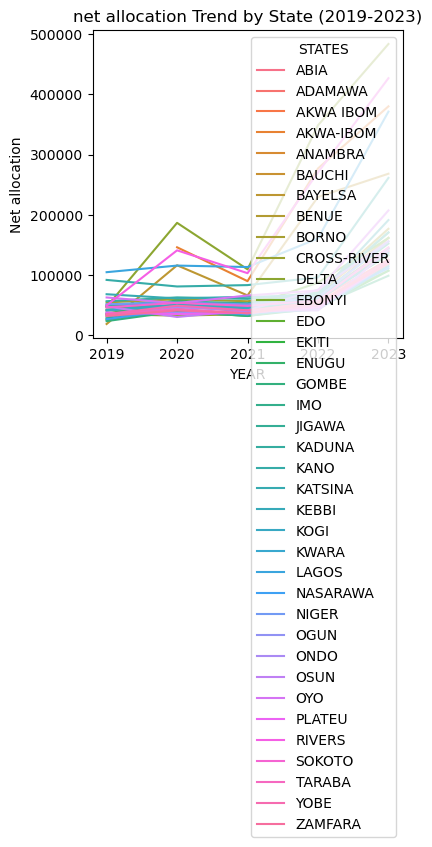

In [29]:
#Exploratory data anlaysis
# Trend over time
plt.figure(figsize=(4,4))
sns.lineplot(data=wage.reset_index(), x='YEAR', y='X2', hue='STATES', legend=True
            )
plt.title("net allocation Trend by State (2019-2023)")
plt.ylabel("Net allocation")
plt.show()

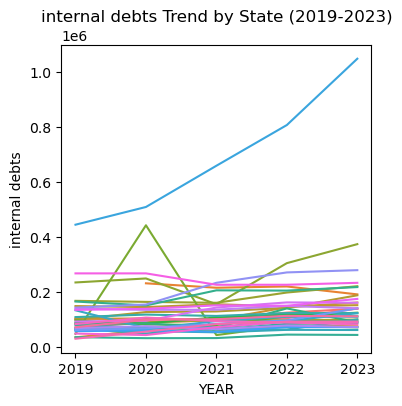

In [30]:
plt.figure(figsize=(4,4))
sns.lineplot(data=wage.reset_index(), x='YEAR', y='X3', hue='STATES', legend=None
            )
plt.title("internal debts Trend by State (2019-2023)")
plt.ylabel("internal debts")
plt.show()

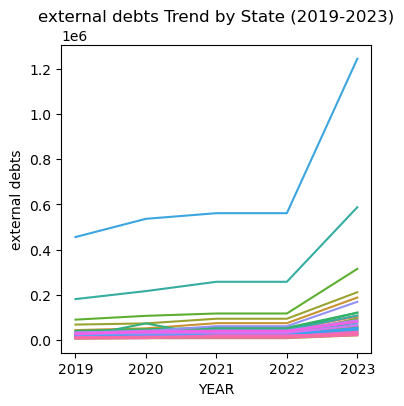

In [31]:
plt.figure(figsize=(4,4))
sns.lineplot(data=wage.reset_index(), x='YEAR', y='X4', hue='STATES', legend=None
            )
plt.title("external debts Trend by State (2019-2023)")
plt.ylabel("external debts")
plt.show()

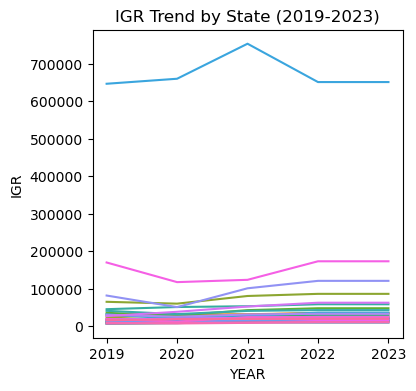

In [9]:
plt.figure(figsize=(4,4))
sns.lineplot(data=wage.reset_index(), x='YEAR', y='X5', hue='STATES', legend=None
            )
plt.title("IGR Trend by State (2019-2023)")
plt.ylabel("IGR")
plt.show()

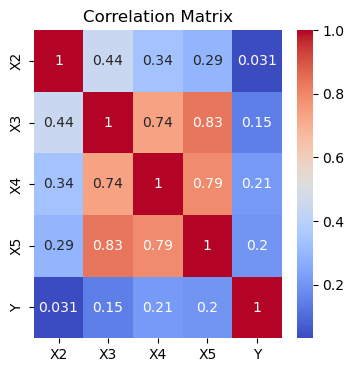

In [10]:
# Correlation heatmap for numeric features
plt.figure(figsize=(4,4))
sns.heatmap(wage[['X2','X3','X4','X5','Y']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
wage=wage.set_index(['STATES','YEAR'])

In [12]:
wage.index

MultiIndex([(   'ABIA', 2019),
            (   'ABIA', 2020),
            (   'ABIA', 2021),
            (   'ABIA', 2022),
            (   'ABIA', 2023),
            ('ADAMAWA', 2019),
            ('ADAMAWA', 2020),
            ('ADAMAWA', 2021),
            ('ADAMAWA', 2022),
            ('ADAMAWA', 2023),
            ...
            (   'YOBE', 2019),
            (   'YOBE', 2020),
            (   'YOBE', 2021),
            (   'YOBE', 2022),
            (   'YOBE', 2023),
            ('ZAMFARA', 2019),
            ('ZAMFARA', 2020),
            ('ZAMFARA', 2021),
            ('ZAMFARA', 2022),
            ('ZAMFARA', 2023)],
           names=['STATES', 'YEAR'], length=180)

In [13]:
#panel structure
wage.index.get_level_values('YEAR').unique()

Index([2019, 2020, 2021, 2022, 2023], dtype='int64', name='YEAR')

In [14]:
#predictive modelling
features = ['X1','X2','X3','X4','X5'] 
X = wage[features]
y = wage['Y']

In [15]:
#train, test and split
#train = 2019-2022, test = 2023
train = wage[wage.index.get_level_values('YEAR') < 2023]
test  = wage[wage.index.get_level_values('YEAR') == 2023]

In [16]:
train.shape,test.shape

((144, 6), (36, 6))

In [17]:
X_train = train[features]
y_train = train['Y']
X_test = test[features]
y_test = test['Y']

In [18]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [19]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7222222222222222
[[ 6  9]
 [ 1 20]]
              precision    recall  f1-score   support

           0       0.86      0.40      0.55        15
           1       0.69      0.95      0.80        21

    accuracy                           0.72        36
   macro avg       0.77      0.68      0.67        36
weighted avg       0.76      0.72      0.69        36



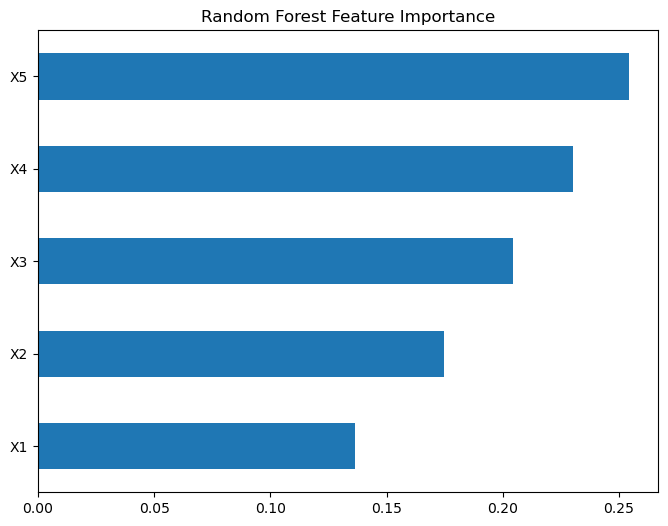

In [20]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=features)  
importances.sort_values().plot(kind='barh', figsize=(8,6), title="Random Forest Feature Importance")
plt.show()

In [21]:
# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb

C:\Users\USER\anaconda3\New folder\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:50:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0])

In [22]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8055555555555556
[[11  4]
 [ 3 18]]
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        15
           1       0.82      0.86      0.84        21

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.80      0.81      0.80        36



In [23]:
# Cluster states based on feature averages
state_features = wage.groupby('STATES')[['X2','X3','X4','X5']].mean()

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)
state_features['cluster'] = kmeans.fit_predict(state_features)
state_features.reset_index()[['STATES','cluster']].sort_values('cluster')

C:\Users\USER\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,STATES,cluster
0,ABIA,0
19,KANO,0
20,KATSINA,0
21,KEBBI,0
22,KOGI,0
23,KWARA,0
25,NASARAWA,0
35,YOBE,0
26,NIGER,0
28,ONDO,0


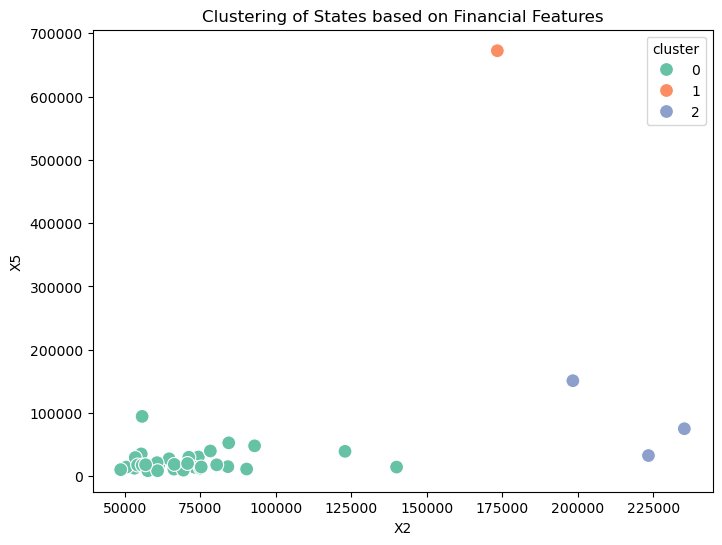

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='X2', y='X5', hue='cluster', data=state_features, palette='Set2', s=100)
plt.title("Clustering of States based on Financial Features")
plt.show()